In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import xarray as xr
from vecchia_spatial_regression import train_test_split

In [6]:
trace_path = 'trace_model.nc'
print('Loading trace from', trace_path)
idata = az.from_netcdf(trace_path)
# quick overview
print(idata)

# summary for all parameters (including betas)
sum_df = az.summary(idata, round_to=3)
display(sum_df)

# save summary to CSV for later reference
sum_df.to_csv('trace_summary.csv')
print('Saved summary to trace_summary.csv')

Loading trace from trace_model.nc
Inference data with groups:
	> posterior
	> sample_stats


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],7.973,0.306,7.404,8.535,0.009,0.012,1599.028,1188.053,1.001
beta[1],0.561,0.056,0.462,0.673,0.001,0.001,1973.588,2285.371,1.001
beta[2],0.333,0.061,0.222,0.445,0.001,0.001,2964.240,2593.929,1.000
beta[3],0.892,0.054,0.796,0.996,0.001,0.001,2322.362,2349.144,1.000
beta[4],-0.160,0.048,-0.252,-0.072,0.001,0.001,2764.514,2380.488,1.001
beta[5],0.420,0.042,0.345,0.499,0.001,0.001,2816.078,2581.748,1.001
log_sigma2,-1.040,0.459,-1.848,-0.144,0.014,0.008,1017.672,976.095,1.000
nugget_ratio,3.185,1.455,1.001,5.670,0.040,0.026,1019.228,976.523,1.000
inv_phi,332.501,150.382,111.258,605.049,4.677,5.029,1293.818,1254.763,1.000
sigma2,0.393,0.191,0.118,0.781,0.007,0.006,1017.672,976.095,1.000


Saved summary to trace_summary.csv


Plotting variables: ['beta', 'nugget_ratio', 'inv_phi', 'sigma2', 'tau2']


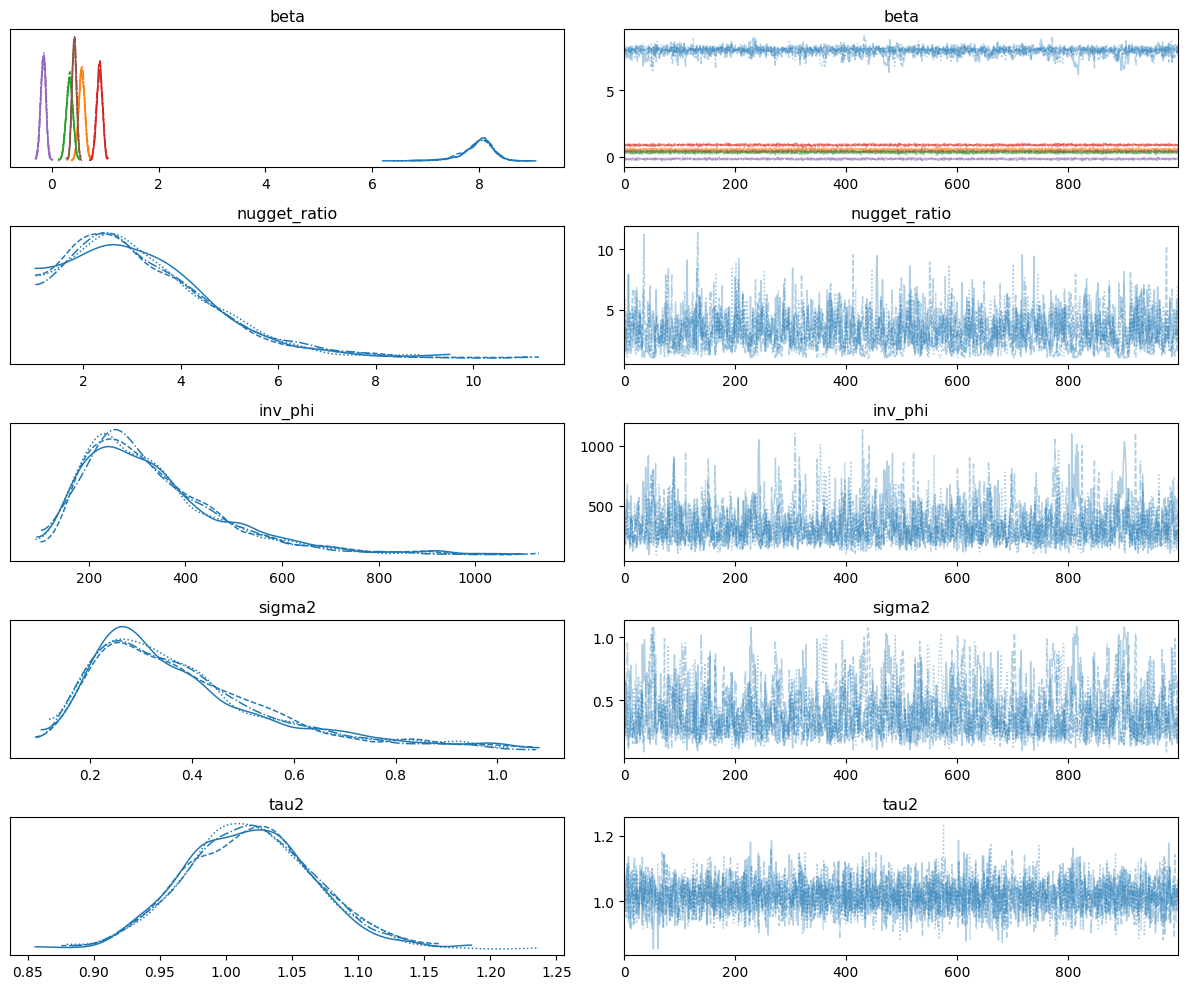

In [19]:
# Traceplots and posterior plots for main parameters
import matplotlib.pyplot as plt
%matplotlib inline

# choose variables to show (common names from model)
var_candidates = [v for v in list(idata.posterior.data_vars) if ('beta' in v) or v in ['sigma2','tau2','inv_phi','nugget_ratio']]
print('Plotting variables:', var_candidates)

# trace plot (will create subplots automatically)
az.plot_trace(idata, var_names=var_candidates, compact=True)
plt.tight_layout()
plt.savefig("nngp_trace.pdf")

# forest (interval) plot for betas if present
# beta_vars = [v for v in var_candidates if 'beta' in v]
# if beta_vars:
#     az.plot_forest(idata, var_names=beta_vars, combined=True)
#     plt.title('Posterior intervals for betas')
#     plt.tight_layout()

# # pairplot for a few key parameters
# pair_vars = [v for v in ['sigma2','tau2','inv_phi','nugget_ratio'] if v in idata.posterior.data_vars][:4]
# if pair_vars:
#     az.plot_pair(idata, var_names=pair_vars, kind='kde', marginals=True)
#     plt.tight_layout()

In [15]:
# Extract posterior means for beta coefficients and save as DataFrame
# arviz stores beta often as a variable like 'beta' with shape (chain, draw, dim), or as 'beta[0]'-style vars.
import numpy as np

# try to handle common storage patterns for betas
posterior = idata.posterior
beta_values = None
if 'beta' in posterior.data_vars:
    # shape (chain, draw, dim)
    arr = posterior['beta'].values
    # combine chain/draw dims
    comb = arr.reshape(-1, arr.shape[-1])
    beta_values = comb
else:
    # collect vars named like 'beta[0]', 'beta[1]', ...
    beta_keys = sorted([k for k in posterior.data_vars if k.startswith('beta')])
    if beta_keys:
        arrs = [posterior[k].values.reshape(-1) for k in beta_keys]
        beta_values = np.vstack(arrs).T

if beta_values is None:
    print('No beta variables found in posterior data_vars. Available vars:', list(posterior.data_vars))
else:
    beta_means = beta_values.mean(axis=0)
    beta_sds = beta_values.std(axis=0, ddof=1)
    df_beta = pd.DataFrame({'mean': beta_means, 'sd': beta_sds})
    # attempt to read covariate names from NPZ (if present)
    try:
        npz = np.load('trace_model_data.npz', allow_pickle=True)
        covs = list(npz.get('covariates', []))
        # add intercept name if dims match (intercept + covs)
        if len(df_beta) == len(covs) + 1:
            names = ['intercept'] + covs
        else:
            names = [f'beta[{i}]' for i in range(len(df_beta))]
    except Exception:
        names = [f'beta[{i}]' for i in range(len(df_beta))]
    df_beta.index = names
    display(df_beta)
    df_beta.to_csv('beta_posterior_means.csv')
    print('Saved beta posterior means to beta_posterior_means.csv')

,mean,sd
intercept,7.972870,0.305620
prop_college_degree_or_higher_18plus,0.561277,0.055954
election_diff,0.332520,0.060604
log_contrib_2020,0.892464,0.054000
log_income,-0.159864,0.048079
log_population,0.420170,0.041727


Saved beta posterior means to beta_posterior_means.csv


In [9]:
df = pd.read_csv("../data/obs_chosen.csv")
train, test = train_test_split(df)

In [10]:
test

,Unnamed: 0,ZIP_CODE,STATE,lat,lon,prop_high_school_or_higher_18plus,prop_college_degree_or_higher_18plus,election_diff,log_contrib_2020,log_contrib_2022,log_income,log_population
0,1397,7823,NJ,40.8308,-75.0503,0.947690,0.229131,-1,7.625595,7.488294,11.356529,8.868132
1,1454,8012,NJ,39.7901,-75.0367,0.940267,0.317135,-1,8.169903,8.815518,11.466368,10.560515
2,1462,8028,NJ,39.7068,-75.1172,0.934154,0.298237,-1,7.714231,7.258412,11.397851,10.119324
3,1466,8035,NJ,39.8788,-75.0664,0.972726,0.557005,-1,7.192182,7.451242,11.786975,8.930097
4,1490,8079,NJ,39.5591,-75.4521,0.875550,0.200761,-1,6.311735,6.368187,10.908540,9.286653
...,...,...,...,...,...,...,...,...,...,...,...,...
1024,8702,49706,MI,45.4405,-84.7924,0.925485,0.294660,-1,8.240385,6.792344,11.250339,8.529517
1025,8710,49721,MI,45.6080,-84.4867,0.900093,0.208443,-1,8.955706,7.889834,11.021478,9.550947
1026,8724,49759,MI,45.4309,-84.0854,0.913864,0.231337,-1,8.027150,3.258097,10.949824,7.316548
1027,8726,49765,MI,45.3365,-84.2123,0.897348,0.142857,-1,5.860786,5.398163,10.957869,8.268219


In [16]:
# Compute test MSE using posterior-mean parameters and Vecchia conditional means
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import arviz as az

trace_path = 'trace_model.nc'
model_data_path = 'trace_model_data.npz'
full_data_path = '../data/obs_chosen.csv'

print('Loading trace from', trace_path)
idata = az.from_netcdf(trace_path)
md = np.load(model_data_path, allow_pickle=True)
X_train = md['X']
y_train = md['y']
coords_train = md['coords_km']
covariates = list(md['covariates'])
x_means = md['x_means']
x_sds = md['x_sds']

df = pd.read_csv(full_data_path)
train_df = df.sample(frac=0.8, random_state=305)
test_df = df.drop(train_df.index).reset_index(drop=True)

# prepare X_test using training scaling
x_raw = test_df[covariates].astype(float).to_numpy()
x_scaled = (x_raw - x_means) / x_sds
X_test = np.column_stack([np.ones(len(test_df)), x_scaled])
y_test = test_df['log_contrib_2022'].astype(float).to_numpy()

kernel = idata.attrs.get('kernel', 'matern32')
m_neighbors = int(idata.attrs.get('m_neighbors', 30))
jitter = 1e-6

def kernel_np(d, sigma2, phi, kernel='matern32'):
    if kernel == 'matern32':
        r = np.sqrt(3.0) * phi * d
        return sigma2 * (1.0 + r) * np.exp(-r)
    if kernel == 'expquad':
        return sigma2 * np.exp(-((phi * d) ** 2))
    raise ValueError(f'unknown kernel: {kernel}')

post = idata.posterior
beta_mean = post['beta'].mean(dim=('chain','draw')).values.reshape(-1)
sigma2_mean = float(post['sigma2'].mean(dim=('chain','draw')).values)
tau2_mean = float(post['tau2'].mean(dim=('chain','draw')).values)
phi_mean = float(post['phi'].mean(dim=('chain','draw')).values)

resid_train = y_train - (X_train @ beta_mean)
tree = cKDTree(coords_train)
n_test = X_test.shape[0]
y_hat = np.empty(n_test, dtype=float)
n_train = coords_train.shape[0]
k = min(m_neighbors, n_train)

# simple lon/lat -> km projection (same fallback used in script)
lat0 = np.deg2rad(np.nanmean(df['lat']))
for i in range(n_test):
    lon, lat = test_df[['lon','lat']].iloc[i].to_numpy().astype(float)
    x = 111.320 * np.cos(lat0) * lon
    y = 110.574 * lat
    coord_km = np.array([x, y])
    dists, ids = tree.query(coord_km, k=k)
    ids = np.atleast_1d(ids).astype(int)
    dists = np.atleast_1d(dists).astype(float)
    if ids.size == 0:
        cond_mean = 0.0
    else:
        diN = dists
        dNN = np.linalg.norm(coords_train[ids][:, None, :] - coords_train[ids][None, :, :], axis=-1)
        c_iN = kernel_np(diN, sigma2_mean, phi_mean, kernel)
        C_NN = kernel_np(dNN, sigma2_mean, phi_mean, kernel)
        C_NN = C_NN + (tau2_mean + jitter) * np.eye(len(ids))
        weights = np.linalg.solve(C_NN, c_iN)
        cond_mean = float(weights @ resid_train[ids])
    y_hat[i] = (X_test[i] @ beta_mean) + cond_mean

mse = float(np.mean((y_test - y_hat) ** 2))
print(f'Test MSE (posterior-mean prediction): {mse:.5f}')

out_df = pd.DataFrame({'y_test': y_test, 'y_hat': y_hat, 'resid': y_test - y_hat})
out_df.to_csv('test_predictions.csv', index=False)
print('Saved test predictions to test_predictions.csv')

Loading trace from trace_model.nc
Test MSE (posterior-mean prediction): 1.20415
Saved test predictions to test_predictions.csv


In [17]:
# Baseline test MSE using the training mean (null model)
train_mean = float(train_df['log_contrib_2022'].astype(float).mean())
y_test = test['log_contrib_2022'].astype(float).to_numpy()
mse_baseline = float(np.mean((y_test - train_mean) ** 2))
print(f'Baseline test MSE (train mean): {mse_baseline:.6f} (train mean={train_mean:.6f}, n_test={len(y_test)})')

Baseline test MSE (train mean): 3.405809 (train mean=8.182398, n_test=1029)


In [13]:
train.columns

Index(['Unnamed: 0', 'ZIP_CODE', 'STATE', 'lat', 'lon',
       'prop_high_school_or_higher_18plus',
       'prop_college_degree_or_higher_18plus', 'election_diff',
       'log_contrib_2020', 'log_contrib_2022', 'log_income', 'log_population'],
      dtype='str')

# OLS baseline

In [29]:
train.columns

Index(['Unnamed: 0', 'ZIP_CODE', 'STATE', 'lat', 'lon',
       'prop_high_school_or_higher_18plus',
       'prop_college_degree_or_higher_18plus', 'election_diff',
       'log_contrib_2020', 'log_contrib_2022', 'log_income', 'log_population'],
      dtype='str')

In [38]:
import statsmodels.formula.api as smf

formula = (
    'log_contrib_2022 ~ '
    'prop_college_degree_or_higher_18plus + '
    'election_diff + '
    'log_contrib_2020 + '
    'log_income + '
    'log_population'
)

model_1 = smf.ols(formula, data=train).fit()
np.mean((test['log_contrib_2022'] - model_1.predict(test))**2)


np.float64(1.162681278480602)